In [28]:
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from mpl_toolkits.mplot3d import Axes3D

from sklearn import set_config

from sklearn.cluster import KMeans
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, silhouette_samples, silhouette_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC


In [ ]:
# load data
data_path = "./var_data/origin_train.csv"
df = pd.read_csv(data_path)


In [ ]:
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

df.head()


Dataset shape: (2000, 21)

Column names:
['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g', 'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height', 'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g', 'touch_screen', 'wifi', 'price_range']


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [ ]:
# Check for missing values
print(df.isnull().sum())


battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64


In [ ]:
# Strategy: drop columns/rows with too many NaNs or fill them
# fill numerical columns with mean, categorical with mode
for col in df.columns:
    if df[col].dtype in [np.float64, np.int64]:
        df[col].fillna(df[col].mean(), inplace=True)
    else:
        df[col].fillna(df[col].mode()[0], inplace=True)

print("Remaining missing values:", df.isnull().sum().sum())

Remaining missing values: 0


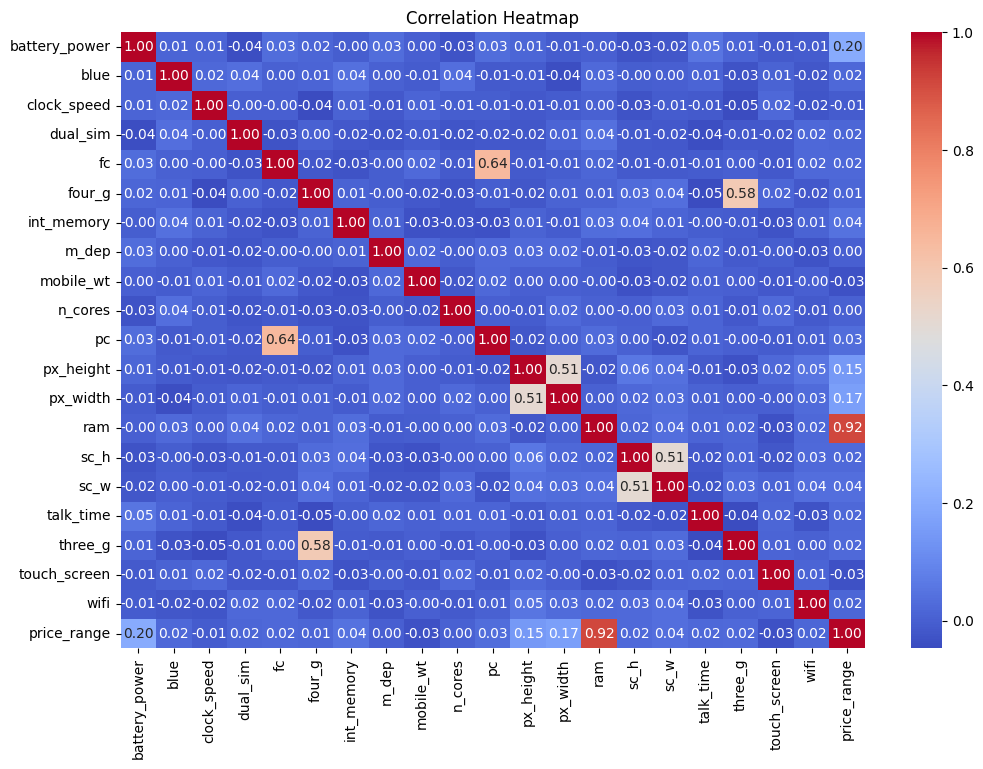

In [ ]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


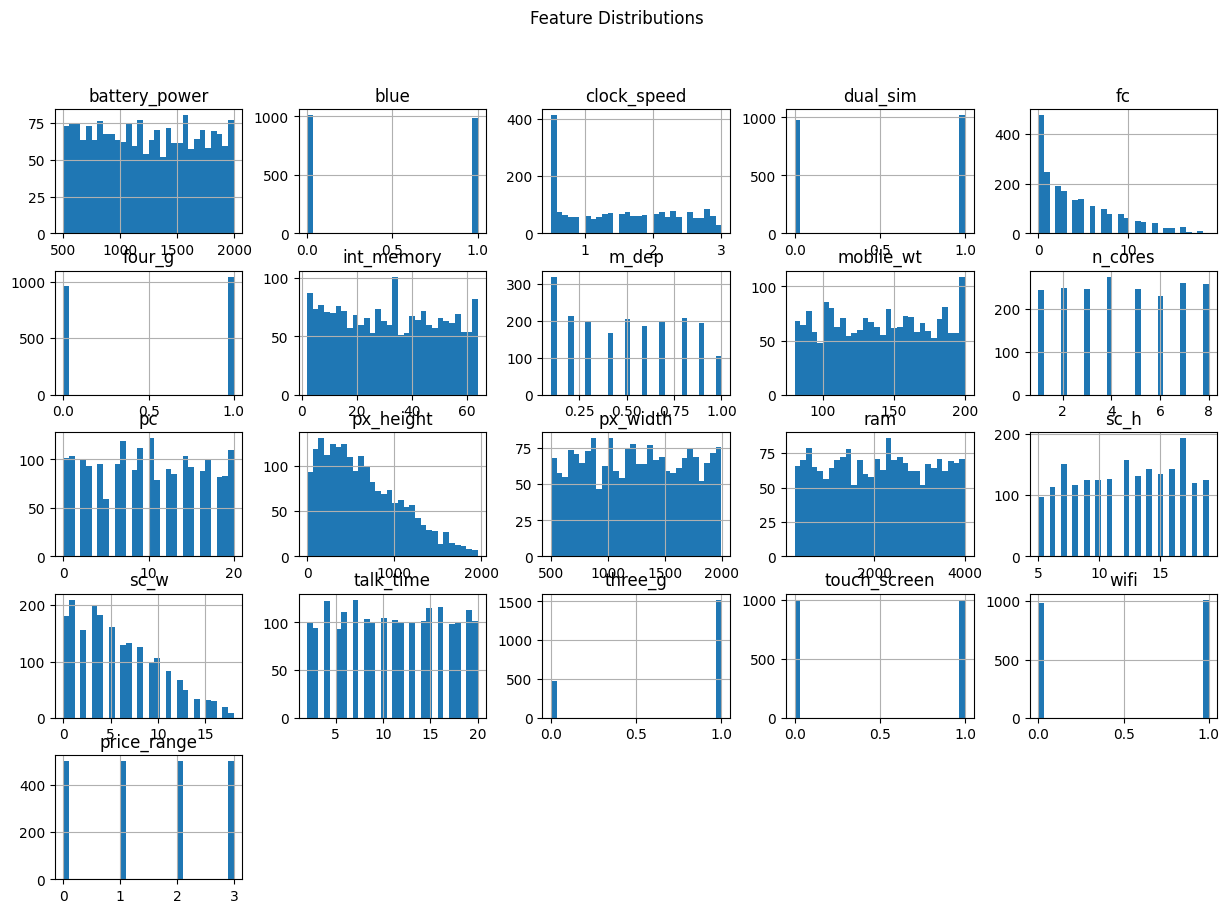

In [22]:
# Histograms for first few features
df.hist(bins=30, figsize=(15, 10))
plt.suptitle("Feature Distributions")
plt.show()


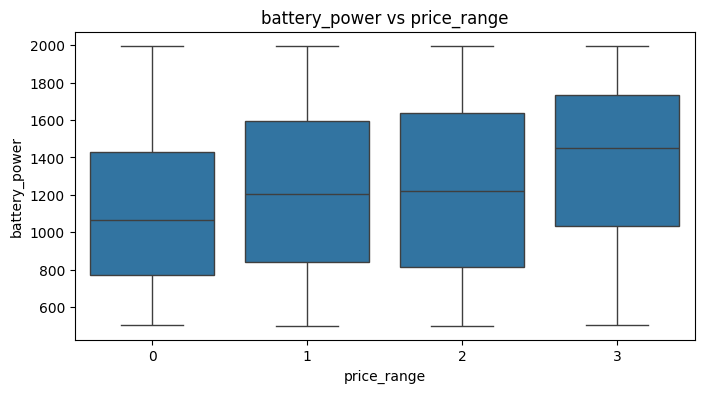

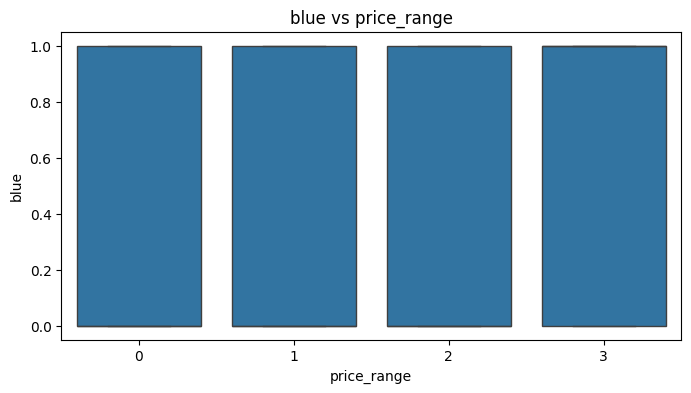

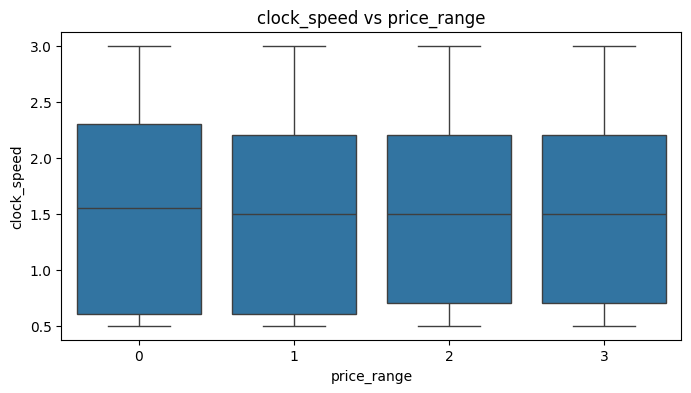

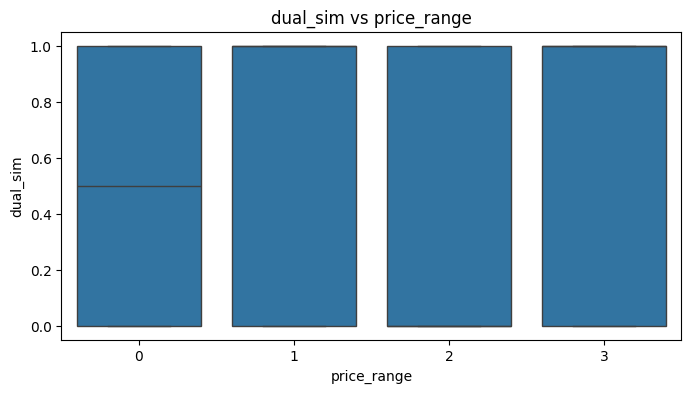

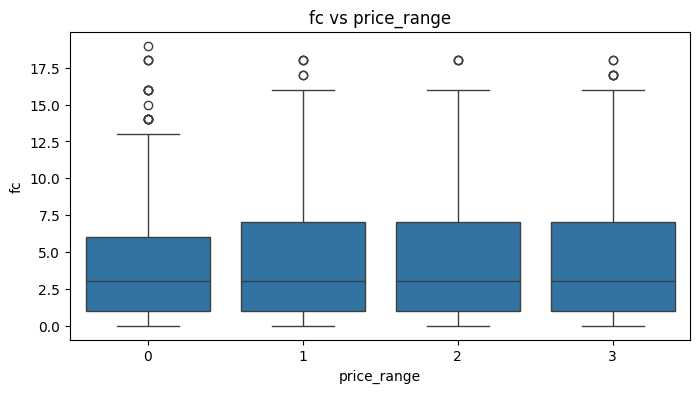

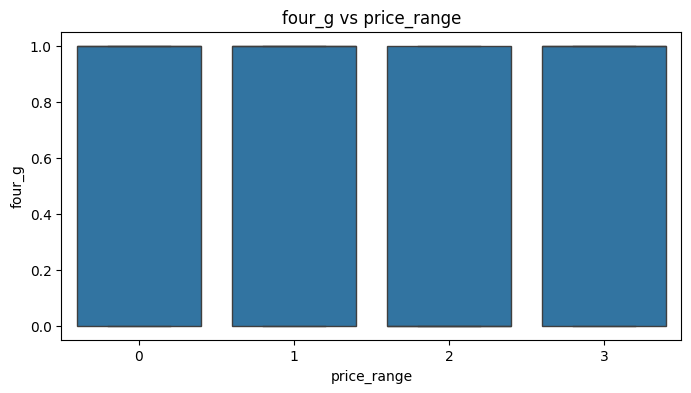

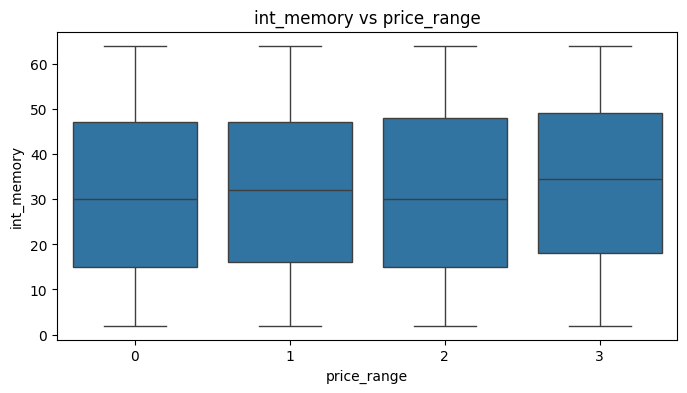

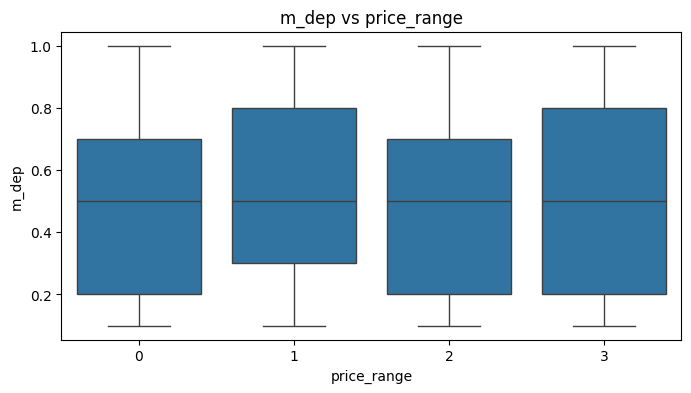

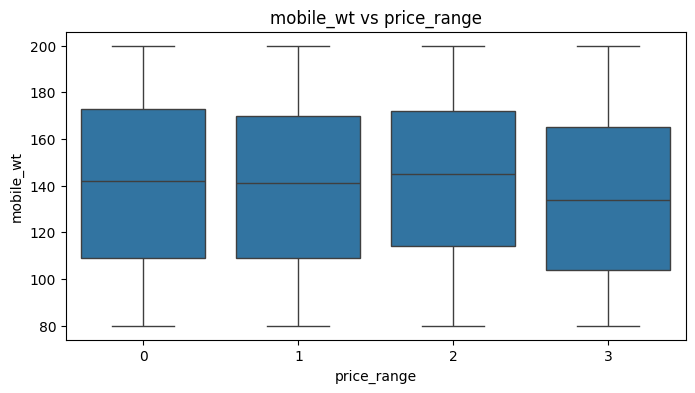

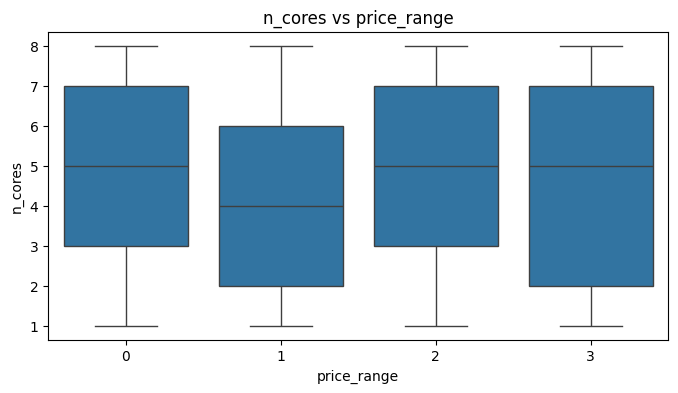

In [24]:
# Pick target column (replace 'target' with actual name)
target_col = "price_range"  # <-- change this after checking your dataset

# Boxplots of features vs target
num_features = df.select_dtypes(include=[np.number]).columns.tolist()
for col in num_features[:10]:   # limit to first 10 features
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[target_col], y=df[col])
    plt.title(f"{col} vs {target_col}")
    plt.show()
    

Normalization using formula: $z = \frac{x - \mu}{\sigma}$, where 
- $x$ = original feature value
- $\mu$ = mean of that feature (per column)
- $\sigma$ = standard deviation of that feature

In [27]:
# Normalize the data
scaler = StandardScaler()

num_features = df.select_dtypes(include=[np.number]).columns.tolist()
num_features.remove(target_col)  # don't scale target

df_scaled = df.copy()
df_scaled[num_features] = scaler.fit_transform(df[num_features])

print("Data normalized (first 10 rows):")
df_scaled.head(10)


Data normalized (first 10 rows):


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,-0.902597,-0.990050,0.830779,-1.019184,-0.762495,-1.043966,-1.380644,0.340740,1.349249,-1.101971,...,-1.408949,-1.146784,0.391703,-0.784983,0.283103,1.462493,-1.786861,-1.006018,0.986097,1
1,-0.495139,1.010051,-1.253064,0.981177,-0.992890,0.957886,1.155024,0.687548,-0.120059,-0.664768,...,0.585778,1.704465,0.467317,1.114266,-0.635317,-0.734267,0.559641,0.994018,-1.014099,2
2,-1.537686,1.010051,-1.253064,0.981177,-0.532099,0.957886,0.493546,1.381165,0.134244,0.209639,...,1.392684,1.074968,0.441498,-0.310171,-0.864922,-0.368140,0.559641,0.994018,-1.014099,2
3,-1.419319,1.010051,1.198517,-1.019184,-0.992890,-1.043966,-1.215274,1.034357,-0.261339,0.646842,...,1.286750,1.236971,0.594569,0.876859,0.512708,-0.002014,0.559641,-1.006018,-1.014099,2
4,1.325906,1.010051,-0.395011,-1.019184,2.002254,0.957886,0.658915,0.340740,0.021220,-1.101971,...,1.268718,-0.091452,-0.657666,-1.022389,-0.864922,0.730240,0.559641,0.994018,-1.014099,1
5,1.412405,-0.990050,-1.253064,0.981177,-0.301703,-1.043966,-0.553795,0.687548,0.671107,-1.539175,...,0.808917,0.931480,-0.974874,1.114266,-1.094526,-0.185077,0.559641,-1.006018,-1.014099,1
6,1.325906,-0.990050,0.217884,-1.019184,-0.071307,0.957886,-1.215274,1.034357,-0.035292,1.521249,...,-0.595280,-0.540431,1.010444,0.164641,0.512708,1.279430,0.559641,-1.006018,0.986097,3
7,1.628654,-0.990050,-1.253064,0.981177,-0.992890,-1.043966,-0.443549,1.034357,1.320993,-0.227564,...,-0.300016,-0.237254,-1.313291,0.876859,-0.635317,-1.100394,0.559641,0.994018,0.986097,0
8,0.470015,1.010051,-1.253064,-1.019184,-0.992890,-1.043966,1.155024,0.687548,0.953666,1.084046,...,-0.584011,-0.961638,-0.945367,1.114266,-1.094526,1.645557,0.559641,-1.006018,-1.014099,0
9,-1.660607,1.010051,-1.130485,0.981177,-0.532099,0.957886,-1.270397,-1.393304,-1.335064,0.209639,...,1.108689,-0.063680,-1.485727,1.589078,0.971917,0.181050,0.559641,-1.006018,-1.014099,0


In [29]:
X = df_scaled.drop(columns=[target_col])
y = df_scaled[target_col]

# Train & test split 70/30
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.3, 
                                                    random_state=42, 
                                                    stratify=y)


In [ ]:
# kNN with GridSearch
param_grid_knn = {"n_neighbors": range(1, 21)}
grid_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn, cv=5)
grid_knn.fit(X_train, y_train)
best_knn = grid_knn.best_estimator_
print("Best kNN params:", grid_knn.best_params_)


Best kNN params: {'n_neighbors': 16}


In [31]:
# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [33]:
# SVM with GridSearch
param_grid_svm = {
    "C": [0.1, 1, 10, 100],
    "gamma": [1, 0.1, 0.01, 0.001],
    "kernel": ["rbf"]
}
grid_svm = GridSearchCV(SVC(), param_grid_svm, cv=5)
grid_svm.fit(X_train, y_train)
best_svm = grid_svm.best_estimator_
print("Best SVM params:", grid_svm.best_params_)


Best SVM params: {'C': 100, 'gamma': 0.001, 'kernel': 'rbf'}
